# **WGANS WITH GRADIENT PENALTY FOR SYNTHESIZING ALZHEIMER'S MRI**

### **IMPORTING THE NECESSARY DEPENDENCIES**

In [21]:
import os
import cv2
import random
import shutil
import warnings
import numpy as np
import seaborn as sns
from tqdm import tqdm
from numpy import cov
from PIL import Image
from numpy import trace
import tensorflow as tf
from numpy import asarray
from tensorflow import keras
from scipy.linalg import sqrtm
from numpy import iscomplexobj
import matplotlib.pyplot as plt
from numpy.random import randint
warnings.filterwarnings("ignore")
from tensorflow.keras import layers
from skimage.transform import resize
from IPython.display import FileLink
from keras.datasets.mnist import load_data
from keras.applications.inception_v3 import InceptionV3
from skimage.metrics import structural_similarity as ssim
from keras.applications.inception_v3 import preprocess_input
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
from tensorflow.keras.callbacks import ModelCheckpoint

### **DECLARING PATHS AND VARIABLES**


In [22]:
tf.random.set_seed(5638)
random.seed(5638)

In [23]:
working_directory = '../../../synthetic_localised/'
os.makedirs(working_directory, exist_ok=True)
dataset_path = '../../../localisation_split/train/'
class_name = 'AD'

noise_dim = 256
IMG_SHAPE = (128, 128, 1)
BATCH_SIZE = 32 #increase to speed up BUT will use up more memory

### **PREPARING THE DATASET**

In [24]:
def prepare_dataset(class_name):
    # Path to the class where the real images are; in the orignal dataset
    class_path = dataset_path + class_name + '/'
    images = [cv2.imread(class_path + image_name, cv2.COLOR_BGR2GRAY) for image_name in os.listdir(class_path)]
    resized_images = np.array([cv2.resize(i, (IMG_SHAPE[0],IMG_SHAPE[1])) for i in images]).astype(np.float32)
    # Reshape each sample to (128, 128, 1) and normalize the pixel values in the [-1, 1] range
    reshaped_images = resized_images.reshape(resized_images.shape[0], *IMG_SHAPE)
    dataset = (reshaped_images - 127.5) / 127.5
    return dataset

train_images = prepare_dataset(class_name)

In [25]:
def conv_block(
    x,
    filters,
    activation,
    kernel_size=(3, 3),
    strides=(1, 1),
    padding="same",
    use_bias=True,
    use_bn=False,
    use_dropout=False,
    drop_value=0.5
    ):

    x = layers.Conv2D(filters, kernel_size, strides=strides, padding=padding, use_bias=use_bias)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = activation(x)
    if use_dropout:
        x = layers.Dropout(drop_value)(x)
    return x

def upsample_block(
    x,
    filters,
    activation,
    kernel_size=(3, 3),
    strides=(1, 1),
    up_size=(2, 2),
    padding="same",
    use_bn=False,
    use_bias=True,
    use_dropout=False,
    drop_value=0.3
    ):

    x = layers.UpSampling2D(up_size)(x)
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding=padding, use_bias=use_bias)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    if activation:
        x = activation(x)
    if use_dropout:
        x = layers.Dropout(drop_value)(x)
    return x

### **CREATE THE DISCRIMINATOR** (the critic in the original WGAN)

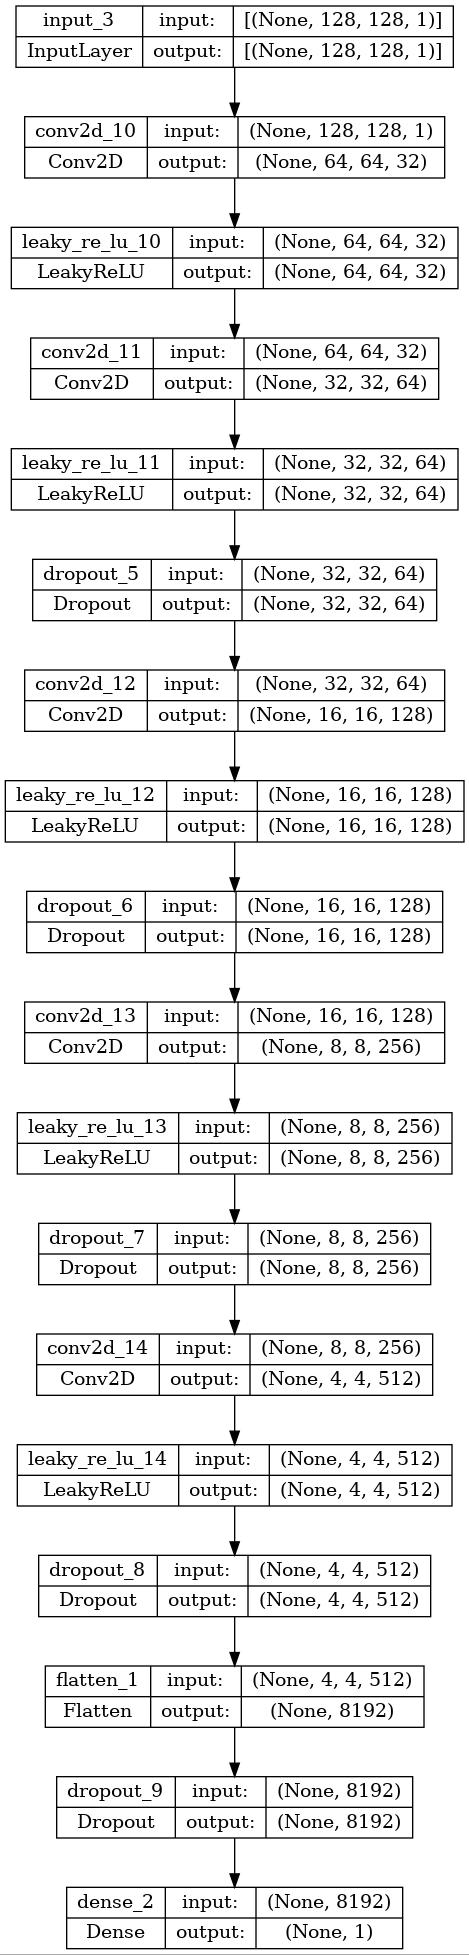

In [26]:
def get_discriminator_model():
    # input = 128 x 128, output = 64 x 64 
    img_input = layers.Input(shape=IMG_SHAPE)
    x = conv_block(
        img_input,
        32,
        activation=layers.LeakyReLU(0.2),
        kernel_size=(5, 5),
        strides=(2, 2),
        padding="same",
        use_bn=False,
        use_bias=True,
        use_dropout=False,
        drop_value=0.3
        )
    
    # input = 64 x 64, output = 32 x 32
    x = conv_block(
        x,
        64,
        activation=layers.LeakyReLU(0.2),
        kernel_size=(5, 5),
        strides=(2, 2),
        padding="same",
        use_bn=False,
        use_bias=True,
        use_dropout=True,
        drop_value=0.3
        )
    
    # input = 32 x 32, output = 16 x 16
    x = conv_block(
        x,
        128,
        activation=layers.LeakyReLU(0.2),
        kernel_size=(5, 5),
        strides=(2, 2),
        padding="same",
        use_bn=False,
        use_bias=True,
        use_dropout=True,
        drop_value=0.3
        )
    
    # input = 16 x 16, output = 8 x 8
    x = conv_block(
        x,
        256,
        activation=layers.LeakyReLU(0.2),
        kernel_size=(5, 5),
        strides=(2, 2),
        padding="same",
        use_bn=False,
        use_bias=True,
        use_dropout=True,
        drop_value=0.3
        )
    
    # input = 8 x 8, output = 4 x 4
    x = conv_block(
        x,
        512,
        activation=layers.LeakyReLU(0.2),
        kernel_size=(5, 5),
        strides=(2, 2),
        padding="same",
        use_bn=False,
        use_bias=True,
        use_dropout=True,
        drop_value=0.3
        )
    
    # input = 4 x 4, output = 1 
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(1)(x)

    d_model = keras.models.Model(img_input, x, name="discriminator")
    return d_model

d_model = get_discriminator_model()
tf.keras.utils.plot_model(d_model, to_file='discriminator.jpg', show_shapes=True, rankdir='TB')

In [27]:
FileLink(r'discriminator.jpg')

/home/anyahabana/MLP-Project/Jupyter Notebooks/Synthetic Image Generation/discriminator.jpg

### **CREATE THE GENERATOR**

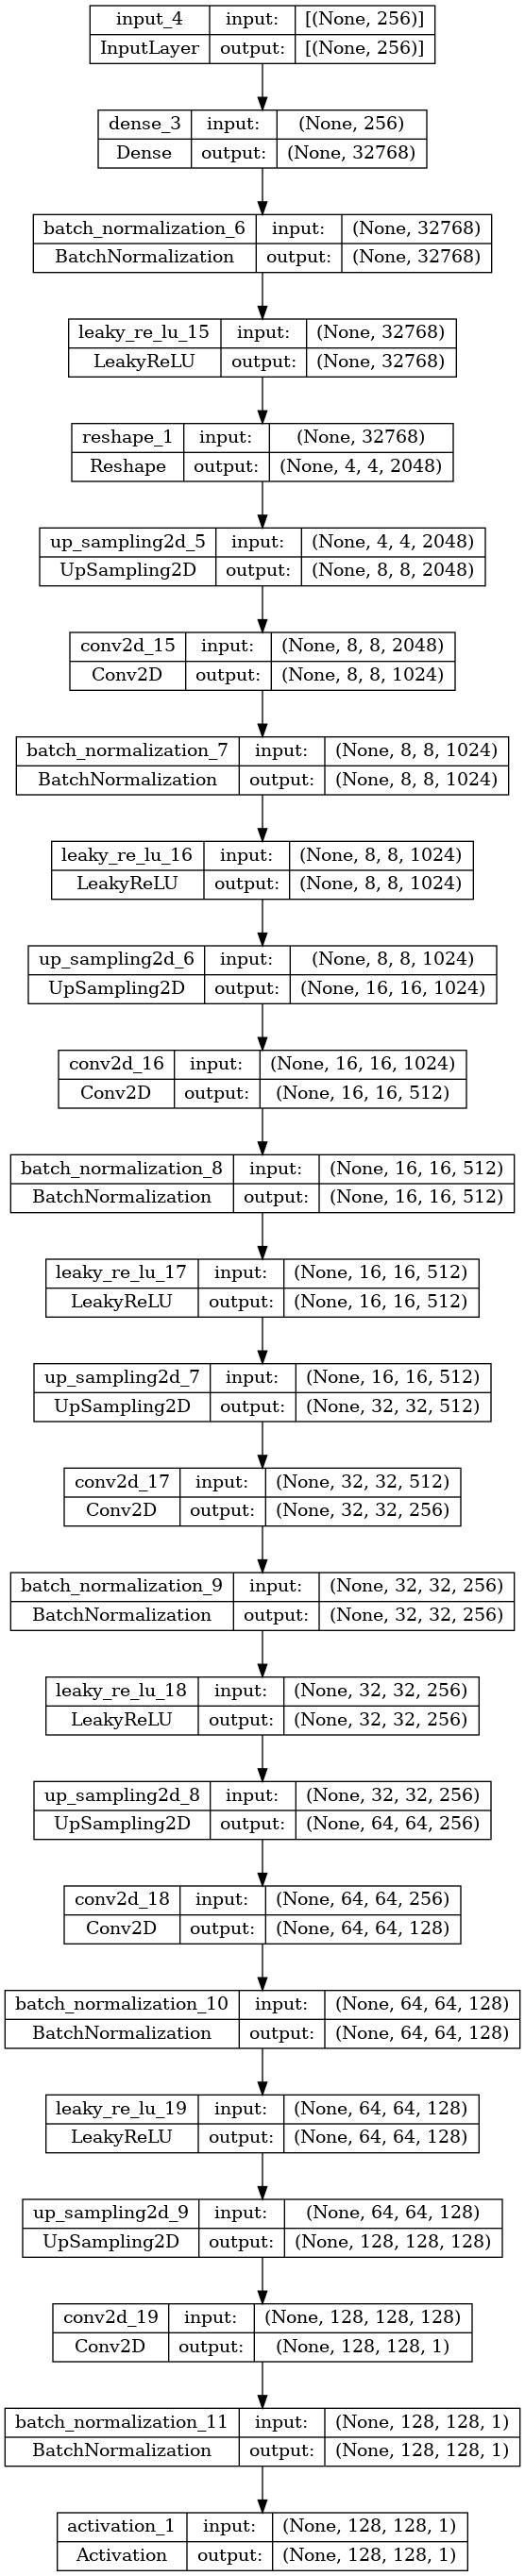

In [28]:
def get_generator_model():
    # input = (noise_dim, ), output = 4 x 4
    noise = layers.Input(shape=(noise_dim,))
    x = layers.Dense(4 * 4 * 2048, use_bias=False)(noise)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((4, 4, 2048))(x)
    
    # input = 4 x 4, output = 8 x 8
    x = upsample_block(
        x,
        1024,
        layers.LeakyReLU(0.2),
        kernel_size =(5, 5),
        strides=(1, 1),
        use_bias=False,
        use_bn=True,
        padding="same",
        use_dropout=False
    )
    
    # input = 8 x 8, output = 16 x 16
    x = upsample_block(
        x,
        512,
        layers.LeakyReLU(0.2),
        kernel_size=(5, 5),
        strides=(1, 1),
        use_bias=False,
        use_bn=True,
        padding="same",
        use_dropout=False
    )
    
    # input = 16 x 16, output = 32 x 32
    x = upsample_block(
        x,
        256,
        layers.LeakyReLU(0.2),
        kernel_size=(5, 5),
        strides=(1, 1),
        use_bias=False,
        use_bn=True,
        padding="same",
        use_dropout=False
    )
    
    # input = 32 x 32, output = 64 x 64
    x = upsample_block(
        x,
        128,
        layers.LeakyReLU(0.2),
        kernel_size=(5, 5),
        strides=(1, 1),
        use_bias=False,
        use_bn=True,
        padding="same",
        use_dropout=False
    )
    
    # input = 64 x 64, output = 128 x 128
    x = upsample_block(x, 1, layers.Activation("tanh"), strides=(1, 1), use_bias=False, use_bn=True)
    
    g_model = keras.models.Model(noise, x, name="generator")
    return g_model


g_model = get_generator_model()
tf.keras.utils.plot_model(g_model, to_file='generator.jpg', show_shapes=True, rankdir='TB')

In [29]:
FileLink('generator.jpg')

/home/anyahabana/MLP-Project/Jupyter Notebooks/Synthetic Image Generation/generator.jpg

### **CREATE THE WGAN-GP MODEL**

Now that we have defined our generator and discriminator, it's time to implement the WGAN-GP model. We will also override the train_step for training.

In [30]:
class WGAN(keras.Model):
    def __init__(
        self,
        discriminator,
        generator,
        latent_dim,
        discriminator_extra_steps=5,
        gp_weight=10.0,
    ):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.d_steps = discriminator_extra_steps
        self.gp_weight = gp_weight

    def compile(self, d_optimizer, g_optimizer, d_loss_fn, g_loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.d_loss_fn = d_loss_fn
        self.g_loss_fn = g_loss_fn 

    def gradient_penalty(self, batch_size, real_images, fake_images):
        """Calculates the gradient penalty.

        This loss is calculated on an interpolated image
        and added to the discriminator loss.
        """
        # Get the interpolated image
        alpha = tf.random.normal([batch_size, 1, 1, 1], 0.0, 1.0)
        diff = fake_images - real_images
        interpolated = real_images + alpha * diff

        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            # 1. Get the discriminator output for this interpolated image.
            pred = self.discriminator(interpolated, training=True)

        # 2. Calculate the gradients w.r.t to this interpolated image.
        grads = gp_tape.gradient(pred, [interpolated])[0]
        # 3. Calculate the norm of the gradients.
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    def train_step(self, real_images):
        if isinstance(real_images, tuple):
            real_images = real_images[0]

        # Get the batch size
        batch_size = tf.shape(real_images)[0]

        # For each batch, we are going to perform the
        # following steps as laid out in the original paper:
        # 1. Train the generator and get the generator loss
        # 2. Train the discriminator and get the discriminator loss
        # 3. Calculate the gradient penalty
        # 4. Multiply this gradient penalty with a constant weight factor
        # 5. Add the gradient penalty to the discriminator loss
        # 6. Return the generator and discriminator losses as a loss dictionary

        # Train the discriminator first. 
        for i in range(self.d_steps):
            # Get the latent vector
            random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
            with tf.GradientTape() as tape:
                # Generate fake images from the latent vector
                fake_images = self.generator(random_latent_vectors, training=True)
                # Get the logits for the fake images
                fake_logits = self.discriminator(fake_images, training=True)
                # Get the logits for the real images
                real_logits = self.discriminator(real_images, training=True)

                # Calculate the discriminator loss using the fake and real image logits
                d_cost = self.d_loss_fn(real_img=real_logits, fake_img=fake_logits)
                # Calculate the gradient penalty
                gp = self.gradient_penalty(batch_size, real_images, fake_images)
                # Add the gradient penalty to the original discriminator loss
                d_loss = d_cost + gp * self.gp_weight

            # Get the gradients w.r.t the discriminator loss
            d_gradient = tape.gradient(d_loss, self.discriminator.trainable_variables)
            # Update the weights of the discriminator using the discriminator optimizer
            self.d_optimizer.apply_gradients(
                zip(d_gradient, self.discriminator.trainable_variables)
            )

        # Train the generator
        # Get the latent vector
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            # Generate fake images using the generator
            generated_images = self.generator(random_latent_vectors, training=True)
            # Get the discriminator logits for fake images
            gen_img_logits = self.discriminator(generated_images, training=True)
            # Calculate the generator loss
            g_loss = self.g_loss_fn(gen_img_logits)

        # Get the gradients w.r.t the generator loss
        gen_gradient = tape.gradient(g_loss, self.generator.trainable_variables)
        # Update the weights of the generator using the generator optimizer
        self.g_optimizer.apply_gradients(
            zip(gen_gradient, self.generator.trainable_variables)
        )

        return {"d_loss": d_loss, "g_loss": g_loss}

### **CREATE A CUSTOM CALLBACK**

In [31]:
def clear_workspace(directory):
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print('Failed to delete %s. Reason: %s' % (file_path, e))

In [32]:
class WGAN_CALLBACK(keras.callbacks.Callback):
    def __init__(self, n_epochs = 20, batch_size = BATCH_SIZE, latent_vector_dim = 128, fid_scores_filepath='fid_scores_localised.npy'):
        self.batch_size = batch_size
        self.noise_dim = latent_vector_dim
        self.fid_scores = []
        self.n_epochs = n_epochs
        self.fid_scores_filepath = fid_scores_filepath
        
        # Load FID scores if they exist
        if os.path.exists(self.fid_scores_filepath):
            self.fid_scores = np.load(self.fid_scores_filepath, allow_pickle=True).tolist()
        
    @property
    def get_fid_scores(self):
        return self.fid_scores
    
    def plot_multiple_images(self,images, n_cols):
        n_cols = n_cols or len(images)
        n_rows = len(images) // n_cols
        if images.shape[-1] == 1:
            images = np.squeeze(images, axis=-1)
        plt.figure(figsize=(n_cols, n_rows))   
        plt.tight_layout()
        plt.suptitle('BEST GENERATOR', fontweight = 'bold')
        for index, image in enumerate(images):
            plt.subplot(n_rows, n_cols, index + 1)
            plt.imshow(image, cmap="gray")
            plt.axis("off")
    
    def calculate_fid(self, generated_images, real_images):
        # scale an array of images to a new size
        def scale_images(images, new_shape):
            images_list = []
            for image in images:
                # resize with nearest neighbor interpolation
                resized_image = cv2.cvtColor(cv2.resize(image, new_shape, cv2.INTER_NEAREST), cv2.COLOR_GRAY2BGR)
                # store the resized images
                images_list.append(resized_image)
            return asarray(images_list)
        # prepare the inception v3 model
        model = InceptionV3(include_top=False, pooling='avg', input_shape=(299,299,3))
        # resize images
        generated_images = scale_images(generated_images, (299,299))
        real_images = scale_images(real_images, (299,299))
        # pre-process images
        generated_images = preprocess_input(generated_images)
        real_images = preprocess_input(real_images)
        # calculate feature embeddings
        embeddings1 = model.predict(generated_images)
        embeddings2 = model.predict(real_images)
        # calculate mean and covariance statistics
        mu1, sigma1 = embeddings1.mean(axis=0), cov(embeddings1, rowvar=False)
        mu2, sigma2 = embeddings2.mean(axis=0), cov(embeddings2, rowvar=False)
        # calculate sum squared difference between means
        ssdiff = np.sum((mu1 - mu2)**2.0)
        # calculate sqrt of product between cov
        covmean = sqrtm(sigma1.dot(sigma2))
        # check and correct imaginary numbers from sqrt
        if iscomplexobj(covmean):
            covmean = covmean.real
        # calculate fid score
        fid = ssdiff + trace(sigma1 + sigma2 - 2.0 * covmean)
        return np.round(fid,2)

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal(shape=(self.batch_size, self.noise_dim))
        generator = self.model.generator
        generated_batch = generator(random_latent_vectors)
        generated_batch = generated_batch.numpy()
        random_number = np.random.randint(train_images.shape[0] - self.batch_size)
        real_batch = train_images[random_number: random_number + self.batch_size]
        current_fid = self.calculate_fid(generated_batch, real_batch)
        self.fid_scores.append(current_fid)  
        print('\033[1mFID SCORE: {}\033[0m'.format(current_fid))
        
        self.model.save_weights(working_directory + "MoI_wgan_weights.h5")
        
        if current_fid <= min(self.fid_scores): #originally 5 as threshold of og paper (got a score of 4.28)
            clear_workspace(working_directory + "best_gen/")
            generator.save(working_directory + "best_gen/" + "MoI_gen_{}_({}).h30".format(epoch+1,current_fid),save_format='h5')
            print("Generator Saved")
        
        # Save FID scores to a file after each epoch
        np.save(self.fid_scores_filepath, np.array(self.fid_scores))

In [33]:
def download_synthetic_images(generator, number_of_images, class_name = 'None'):
    clear_workspace(working_directory)
    # Making sure that no two images have the same name
    counter = 1
    # To check if folder is full
    folder_full = False
    # Folder path to store synthetic images. Folder name is the same as the class name which is inside the working directory
    folder_path = working_directory + 'synthetic_' + class_name + '/'
    images_folder = os.path.join(folder_path)
    # Create this folder if it doesn't exists, otherwise do nothing
    os.makedirs(images_folder, exist_ok=True)
    # Unless I get the desired number of good quality synthetic images in this folder, keep on generating images
    pbar = tqdm(total=number_of_images, position=0, leave=True)
    while len(os.listdir(images_folder)) < number_of_images:
        # Generate a batch of synthetic images
        random_latent_vectors = tf.random.normal(shape=(BATCH_SIZE, noise_dim))
        synthetic_images_batch = generator(random_latent_vectors)
        # Convert tensors to numpy arrays 
        synthetic_images_batch = synthetic_images_batch.numpy()
        # Convert the scale of images from (-1,1) to (0,255) and data type from float to integers 
        for image in synthetic_images_batch:
            image = (image * 127.5) + 127.5
            image = image.astype(np.uint8)
            # If it is a single channel image then save it as it is
            if image.shape[2] == 1:
                cv2.imwrite(images_folder + class_name + ' ({}).jpg'.format(counter), image)
                pbar.update(1)
                # Incrementing the counter so that no two images have the same name
                counter += 1
            # If it is a 3 channel image then first convert it to grayscale and then save it
            elif image.shape[2] == 3:
                gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                cv2.imwrite(images_folder + ' ({}).jpg'.format(counter), image)
                pbar.update(1)
                # Incrementing the counter so that no two images have the same name
                counter += 1
            # If the folder now has the number of desired images, then come out of the loop
            if len(os.listdir(images_folder)) >= number_of_images:
                folder_full = True
                break
        if folder_full == True:
                break
            
    # Generate a link from where I can download the synthetic images
    os.system('zip -r synthetic_images.zip {} >/dev/null 2>&1'.format(folder_path))
    return FileLink(r'synthetic_images.zip')

### **TRAIN THE END TO END MODEL**

In [34]:
def train_wgans(dataset, n_epochs, batch_size = BATCH_SIZE, optimizer = 'adam', gen_lr = 0.0001, dis_lr = 0.0001, checkpoint_dir="wgan_checkpoint",
                resume_training=False):
    if not resume_training:
        clear_workspace(working_directory)
        os.makedirs(working_directory + "best_gen/", exist_ok=True) 
        if os.path.exists('fid_scores_localised.npy'):
            os.remove('fid_scores_localised.npy')
    assert optimizer in ['adam','rmsprop', 'nadam'], "Invalid optimizer. Valid options are 'adam' or 'rmsprop' or 'nadam'."
    if optimizer == 'adam':
        generator_optimizer = keras.optimizers.Adam(learning_rate = gen_lr, beta_1=0, beta_2=0.9)
        discriminator_optimizer = keras.optimizers.Adam(learning_rate = dis_lr, beta_1=0, beta_2=0.9)
    elif optimizer == 'rmsprop':
        generator_optimizer = tf.keras.optimizers.RMSprop(learning_rate = gen_lr)
        discriminator_optimizer = tf.keras.optimizers.RMSprop(learning_rate = dis_lr)
    elif optimizer == 'nadam':
        generator_optimizer = keras.optimizers.Nadam(learning_rate = gen_lr, beta_1=0.5, beta_2=0.9)
        discriminator_optimizer = keras.optimizers.Nadam(learning_rate = dis_lr, beta_1=0.5, beta_2=0.9)

    # Define the loss functions for the discriminator,
    # which should be (fake_loss - real_loss).
    # We will add the gradient penalty later to this loss function.
    def discriminator_loss(real_img, fake_img):
        real_loss = tf.reduce_mean(real_img)
        fake_loss = tf.reduce_mean(fake_img)
        return fake_loss - real_loss

    # Define the loss functions for the generator.
    def generator_loss(fake_img):
        return -tf.reduce_mean(fake_img)

    # Instantiate the customer `WGAN_CALLBACK` Keras callback.
    custom_callback = WGAN_CALLBACK(n_epochs, batch_size = BATCH_SIZE, latent_vector_dim = noise_dim)

    # Get the wgan model
    wgan = WGAN(discriminator = d_model, generator = g_model, latent_dim = noise_dim, discriminator_extra_steps=5)

    # Compile the wgan model
    wgan.compile(
        d_optimizer = discriminator_optimizer,
        g_optimizer = generator_optimizer,
        g_loss_fn = generator_loss,
        d_loss_fn = discriminator_loss
    )
    
    # If resuming training, load the previously saved model
    checkpoint_path = working_directory + "MoI_wgan_weights.h5"
    if resume_training and os.path.exists(checkpoint_path):
        print(f"Resuming training from checkpoint: {checkpoint_path}")
        wgan.load_weights(checkpoint_path)

    # Start training
    wgan_history = wgan.fit(dataset, batch_size = BATCH_SIZE, epochs = n_epochs, callbacks=[custom_callback])
    fid_scores = custom_callback.get_fid_scores
    
    return wgan_history, fid_scores

In [35]:
%%time
wgan_history, fid_scores = train_wgans(dataset = train_images, 
                                        n_epochs = 500, #originally 2000; when resuming training, will train for an additional number of epochs based on what put here
                                        optimizer = 'adam', 
                                        gen_lr = 0.0001, 
                                        dis_lr = 0.0001,
                                        checkpoint_dir="wgan_checkpoint",
                                        resume_training=False) #CHECK: false if first time running, true if resuming from checkpoint

Epoch 1/500


2025-03-17 01:03:37.838412: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8900


1/1 [==============================] - 0s 52ms/step
FID SCORE: 97.17
Generator Saved
41/41 [==============================] - 90s 2s/step - d_loss: -204.8928 - g_loss: 21.3171
Epoch 2/500
1/1 [==============================] - 0s 51ms/step
FID SCORE: 94.66
Generator Saved
41/41 [==============================] - 68s 2s/step - d_loss: -183.3207 - g_loss: -47.0810
Epoch 3/500
1/1 [==============================] - 0s 52ms/step
FID SCORE: 86.09
Generator Saved
41/41 [==============================] - 70s 2s/step - d_loss: -195.9389 - g_loss: -13.9314
Epoch 4/500
1/1 [==============================] - 0s 55ms/step
FID SCORE: 89.62
41/41 [==============================] - 67s 2s/step - d_loss: -200.3704 - g_loss: 135.1630
Epoch 5/500
1/1 [==============================] - 0s 51ms/step
FID SCORE: 95.55
41/41 [==============================] - 67s 2s/step - d_loss: -201.5880 - g_loss: 316.7953
Epoch 6/500
1/1 [==============================] - 0s 52ms/step
FID SCORE: 83.52
Generator Saved
41/

1/1 [==============================] - 0s 50ms/step
FID SCORE: 66.32
41/41 [==============================] - 67s 2s/step - d_loss: -137.0745 - g_loss: 464.6362
Epoch 32/500
1/1 [==============================] - 0s 52ms/step
FID SCORE: 49.82
Generator Saved
41/41 [==============================] - 69s 2s/step - d_loss: -138.5810 - g_loss: 464.6365
Epoch 33/500
1/1 [==============================] - 0s 51ms/step
FID SCORE: 66.89
41/41 [==============================] - 70s 2s/step - d_loss: -137.8292 - g_loss: 509.1556
Epoch 34/500
1/1 [==============================] - 0s 50ms/step
FID SCORE: 51.51
41/41 [==============================] - 67s 2s/step - d_loss: -135.7375 - g_loss: 509.7587
Epoch 35/500
1/1 [==============================] - 0s 51ms/step
FID SCORE: 60.72
41/41 [==============================] - 68s 2s/step - d_loss: -133.1824 - g_loss: 503.6421
Epoch 36/500
1/1 [==============================] - 0s 51ms/step
FID SCORE: 62.4
41/41 [==============================] - 68s 2

1/1 [==============================] - 0s 53ms/step
FID SCORE: 42.02
41/41 [==============================] - 68s 2s/step - d_loss: -84.7642 - g_loss: 341.9053
Epoch 62/500
1/1 [==============================] - 0s 51ms/step
FID SCORE: 54.26
41/41 [==============================] - 69s 2s/step - d_loss: -81.6630 - g_loss: 335.2814
Epoch 63/500
1/1 [==============================] - 0s 76ms/step
FID SCORE: 42.18
41/41 [==============================] - 69s 2s/step - d_loss: -84.3571 - g_loss: 355.8599
Epoch 64/500
1/1 [==============================] - 0s 52ms/step
FID SCORE: 40.71
41/41 [==============================] - 67s 2s/step - d_loss: -77.9453 - g_loss: 338.1983
Epoch 65/500
1/1 [==============================] - 0s 52ms/step
FID SCORE: 53.36
41/41 [==============================] - 67s 2s/step - d_loss: -75.7149 - g_loss: 299.0859
Epoch 66/500
1/1 [==============================] - 0s 53ms/step
FID SCORE: 59.79
41/41 [==============================] - 68s 2s/step - d_loss: -76

...

1/1 [==============================] - 0s 55ms/step
FID SCORE: 8.77
41/41 [==============================] - 69s 2s/step - d_loss: -6.9404 - g_loss: 10.7418
Epoch 371/500
1/1 [==============================] - 0s 53ms/step
FID SCORE: 6.05
Generator Saved
41/41 [==============================] - 69s 2s/step - d_loss: -7.1156 - g_loss: 11.0887
Epoch 372/500
1/1 [==============================] - 0s 52ms/step
FID SCORE: 6.92
41/41 [==============================] - 70s 2s/step - d_loss: -6.6438 - g_loss: 10.3487
Epoch 373/500
1/1 [==============================] - 0s 52ms/step
FID SCORE: 15.93
41/41 [==============================] - 68s 2s/step - d_loss: -7.1753 - g_loss: 9.8364
Epoch 374/500
1/1 [==============================] - 0s 55ms/step
FID SCORE: 9.98
41/41 [==============================] - 68s 2s/step - d_loss: -7.0023 - g_loss: 9.4978
Epoch 375/500
1/1 [==============================] - 0s 52ms/step
FID SCORE: 8.45
41/41 [==============================] - 68s 2s/step - d_loss:

1/1 [==============================] - 0s 53ms/step
FID SCORE: 8.77
41/41 [==============================] - 69s 2s/step - d_loss: -6.2838 - g_loss: 8.4862
Epoch 402/500
1/1 [==============================] - 0s 53ms/step
FID SCORE: 8.23
41/41 [==============================] - 69s 2s/step - d_loss: -6.7241 - g_loss: 9.9013
Epoch 403/500
1/1 [==============================] - 0s 51ms/step
FID SCORE: 9.94
41/41 [==============================] - 67s 2s/step - d_loss: -6.3071 - g_loss: 9.0207
Epoch 404/500
1/1 [==============================] - 0s 53ms/step
FID SCORE: 8.36
41/41 [==============================] - 68s 2s/step - d_loss: -6.7004 - g_loss: 8.9656
Epoch 405/500
1/1 [==============================] - 0s 56ms/step
FID SCORE: 7.36
41/41 [==============================] - 67s 2s/step - d_loss: -7.3066 - g_loss: 9.2664
Epoch 406/500
1/1 [==============================] - 0s 52ms/step
FID SCORE: 7.38
41/41 [==============================] - 68s 2s/step - d_loss: -5.8485 - g_loss: 7

1/1 [==============================] - 0s 59ms/step
FID SCORE: 7.71
41/41 [==============================] - 70s 2s/step - d_loss: -5.4114 - g_loss: 10.5864
Epoch 433/500
1/1 [==============================] - 0s 58ms/step
FID SCORE: 7.43
41/41 [==============================] - 71s 2s/step - d_loss: -6.2946 - g_loss: 8.7050
Epoch 434/500
1/1 [==============================] - 0s 57ms/step
FID SCORE: 11.55
41/41 [==============================] - 70s 2s/step - d_loss: -7.1285 - g_loss: 10.1018
Epoch 435/500
1/1 [==============================] - 0s 60ms/step
FID SCORE: 6.45
41/41 [==============================] - 71s 2s/step - d_loss: -6.3251 - g_loss: 9.2723
Epoch 436/500
1/1 [==============================] - 0s 59ms/step
FID SCORE: 12.83
41/41 [==============================] - 71s 2s/step - d_loss: -6.4097 - g_loss: 9.6417
Epoch 437/500
1/1 [==============================] - 0s 59ms/step
FID SCORE: 7.39
41/41 [==============================] - 70s 2s/step - d_loss: -7.2267 - g_los

Epoch 464/500
1/1 [==============================] - 0s 59ms/step
FID SCORE: 8.73
41/41 [==============================] - 69s 2s/step - d_loss: -6.8669 - g_loss: 6.1869
Epoch 465/500
1/1 [==============================] - 0s 56ms/step
FID SCORE: 11.17
41/41 [==============================] - 69s 2s/step - d_loss: -5.7292 - g_loss: 6.3942
Epoch 466/500
1/1 [==============================] - 0s 57ms/step
FID SCORE: 11.07
41/41 [==============================] - 68s 2s/step - d_loss: -6.3249 - g_loss: 7.1100
Epoch 467/500
1/1 [==============================] - 0s 54ms/step
FID SCORE: 8.35
41/41 [==============================] - 68s 2s/step - d_loss: -7.1061 - g_loss: 6.9663
Epoch 468/500
1/1 [==============================] - 0s 54ms/step
FID SCORE: 7.15
41/41 [==============================] - 70s 2s/step - d_loss: -6.0984 - g_loss: 6.2795
Epoch 469/500
1/1 [==============================] - 0s 80ms/step
FID SCORE: 7.32
41/41 [==============================] - 70s 2s/step - d_loss: -6.

1/1 [==============================] - 0s 53ms/step
FID SCORE: 8.45
41/41 [==============================] - 68s 2s/step - d_loss: -6.6808 - g_loss: 6.4499
Epoch 496/500
1/1 [==============================] - 0s 55ms/step
FID SCORE: 10.19
41/41 [==============================] - 70s 2s/step - d_loss: -6.4398 - g_loss: 4.5000
Epoch 497/500
1/1 [==============================] - 0s 55ms/step
FID SCORE: 9.05
41/41 [==============================] - 69s 2s/step - d_loss: -6.9376 - g_loss: 3.6402
Epoch 498/500
1/1 [==============================] - 0s 55ms/step
FID SCORE: 9.28
41/41 [==============================] - 68s 2s/step - d_loss: -5.9306 - g_loss: 5.7470
Epoch 499/500
1/1 [==============================] - 0s 53ms/step
FID SCORE: 7.38
41/41 [==============================] - 68s 2s/step - d_loss: -6.5739 - g_loss: 4.4940
Epoch 500/500
1/1 [==============================] - 0s 52ms/step
FID SCORE: 7.98
41/41 [==============================] - 68s 2s/step - d_loss: -5.6818 - g_loss: 

### **GET FID_SCORES & PLOT IMAGES**

In [36]:
min_fid_unrounded = min(fid_scores)
min_fid_unrounded

5.89

In [37]:
rounded_fid_scores = [np.round(i) for i in fid_scores]
min_fid = min(rounded_fid_scores)
latest_epoch_for_min_fid = 1 + max([epoch for epoch,fid_score in enumerate(rounded_fid_scores) if fid_score == min_fid])
print(latest_epoch_for_min_fid)

486


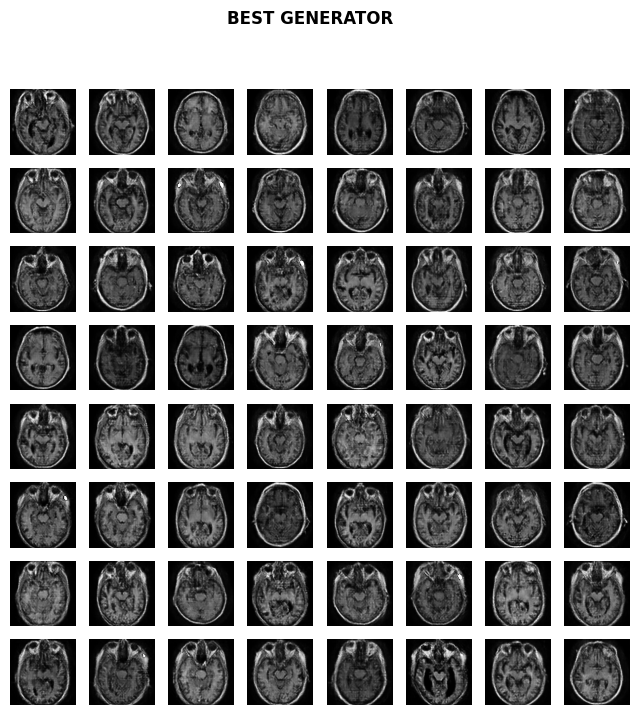

In [41]:
# take best generator and plot 64 images with it
try:
    best_gen_file = f"MoI_gen_{422}_({min_fid_unrounded}).h30"
    best_generator = tf.keras.models.load_model(working_directory + "best_gen/" + best_gen_file)
    random_latent_vectors = tf.random.normal(shape=(64, noise_dim))
    generated_batch = best_generator(random_latent_vectors)
    synthetic_images = generated_batch.numpy()
    WGAN_CALLBACK().plot_multiple_images(synthetic_images, 8)                    
    plt.show()
except Exception as e:
    print(f"An error occurred: {e}")

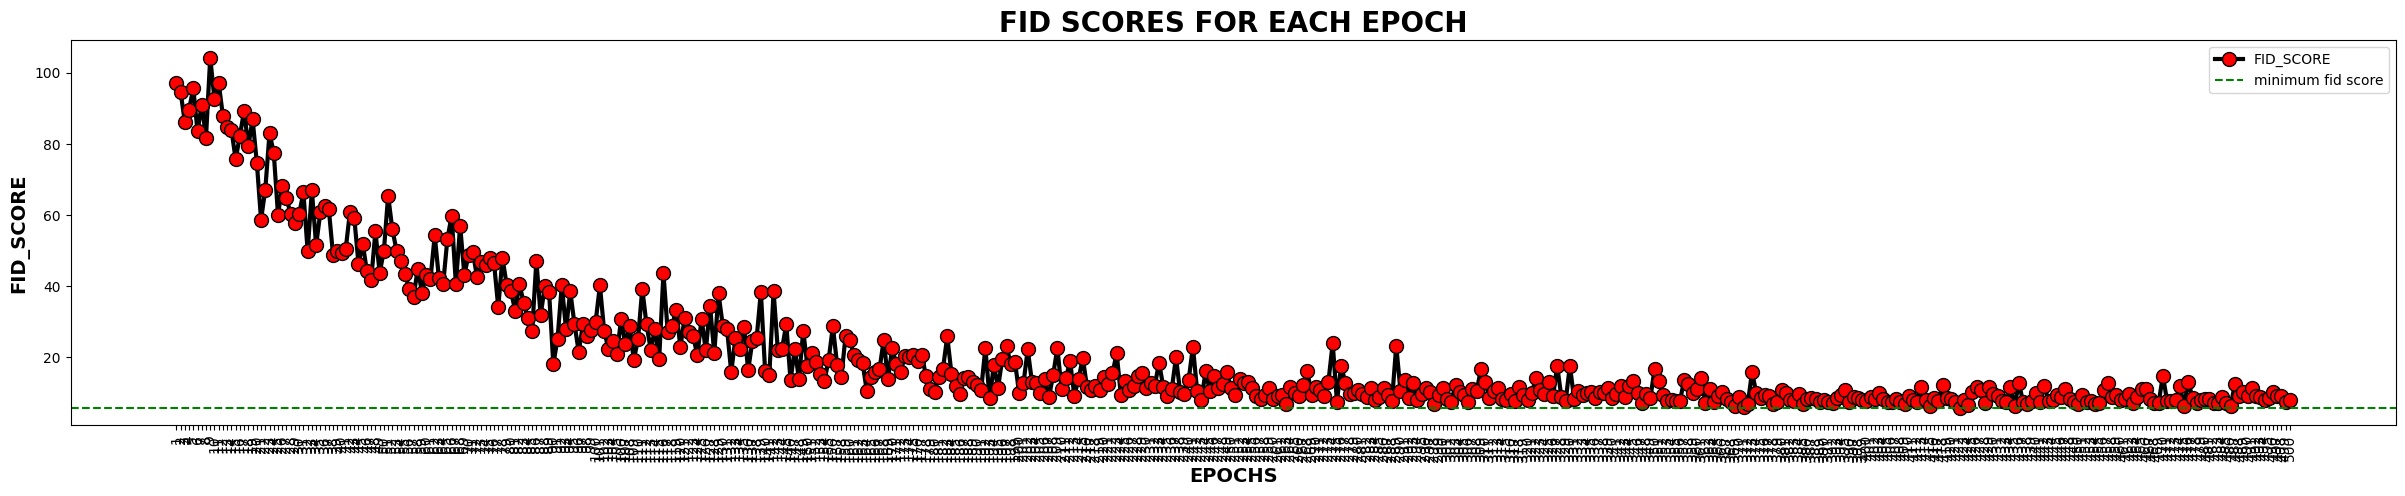

In [42]:
# Plotting fid scores corresponding to each epoch
plt.figure(figsize = (30,5))
plt.plot(fid_scores, linewidth = 3, linestyle = '-', marker = 'o', markersize = 10, markerfacecolor='red', label = "FID_SCORE", color = 'k')
plt.axhline(y = min(fid_scores), color = 'green', linestyle = '--', label = 'minimum fid score')
plt.xlabel("EPOCHS", fontsize = 14, fontweight = 'bold')
plt.ylabel("FID_SCORE", fontsize = 14, fontweight = 'bold')
plt.xticks(np.arange(len(fid_scores)),np.arange(1,len(fid_scores)+1),rotation=90)
plt.legend()
plt.title("FID SCORES FOR EACH EPOCH", fontsize = 20, fontweight = 'bold')
plt.show()

### **PLOTTING GENERATOR VS DISCRIMINATOR LOSSES**

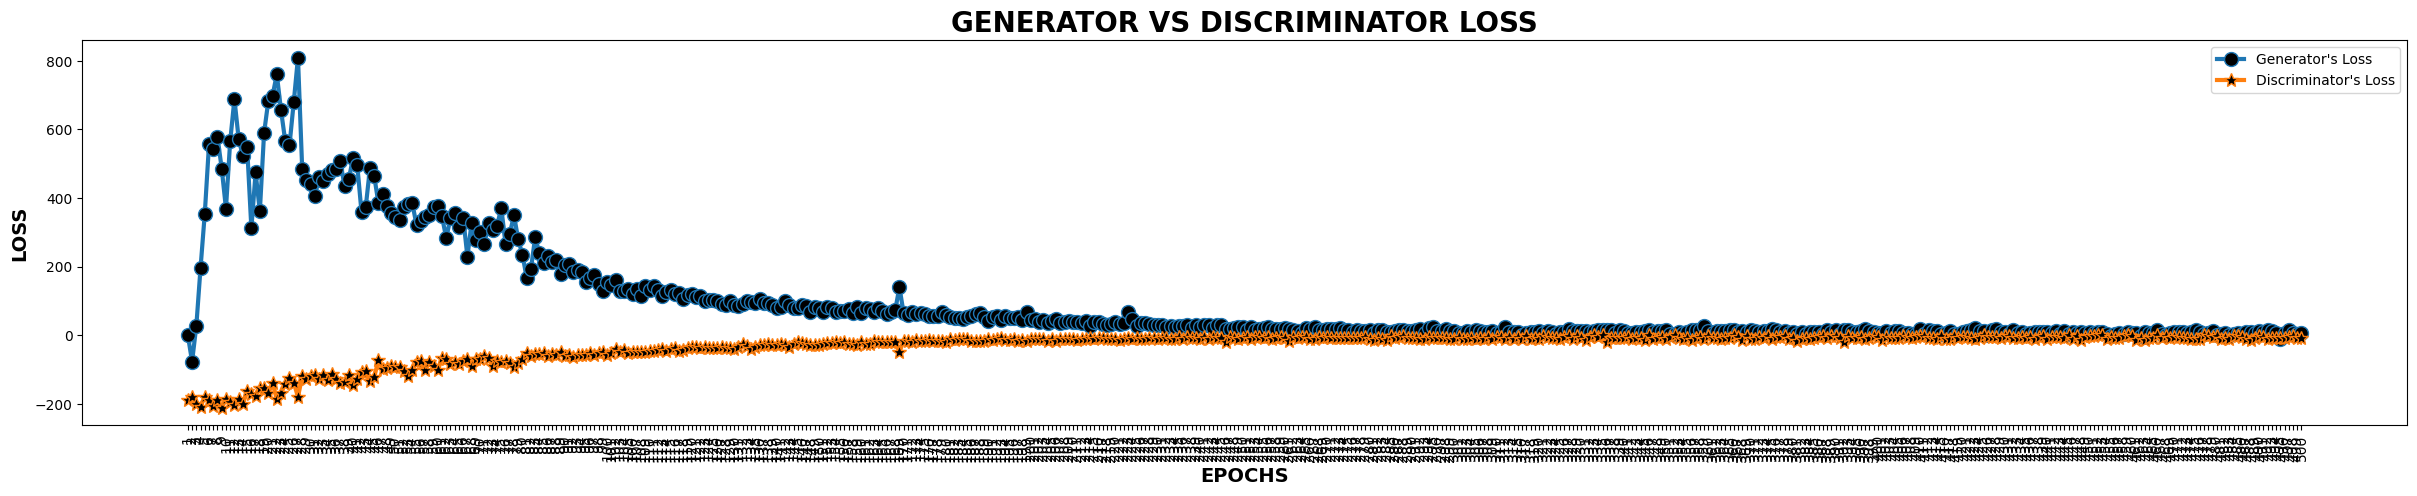

In [43]:
plt.figure(figsize = (30,5))
plt.plot(wgan_history.history['g_loss'], linewidth = 3, marker = 'o', markersize = 10, markerfacecolor='k',label = "Generator's Loss")
plt.plot(wgan_history.history['d_loss'], linewidth = 3, marker = '*', markersize = 10, markerfacecolor='k',label = "Discriminator's Loss")
plt.xlabel("EPOCHS", fontsize = 14, fontweight = 'bold')
plt.ylabel("LOSS", fontsize = 14, fontweight = 'bold')
plt.xticks(np.arange(len(wgan_history.history['g_loss'])),np.arange(1,len(wgan_history.history['g_loss'])+1),rotation=90)
plt.legend()
plt.title("GENERATOR VS DISCRIMINATOR LOSS", fontsize = 20, fontweight = 'bold')
plt.show()